In [1]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

# V-n Diagrams with Gusts
## EAE 130B, SQ 2026

Last edit: Huanglun Adam. Zhu - 4/23/2026

First, let us paint the big picture. We wish to find the flight envelope of our aircraft. This is essential for aircraft performance assessment! It is done at this point in the design process to allow adjustments in the structure of the aircraft, if needed. Let's see how (this tutorial uses data for the Boeing 787-8).

### Part 1. The V-n diagram
The V-n diagram relates the load factor $n$ with velocity $V$.

$$ n = \frac{L}{W} = \frac{\frac{1}{2}\rho_\infty V_\infty^2 C_L}{\frac{W}{S}}$$

We notice that the relationship between $n$ and $V$ depends on density $\rho$, lift coefficient $C_L$ and wing loading $\frac{W}{S}$. 

$$ n = c_{stall} \cdot V_{\infty}^2 $$

 where $$c_{stall} = \frac{\frac{1}{2}\rho_\infty C_L}{\frac{W}{S}}$$

So how do we find the limiting load factor? The aircraft stalls at $C_L > C_{L_{max}}$, providing us with our first restriction.

Computing stall boundary...
W/S: 6819.771 N/m^2
Stall coefficient: 0.000144


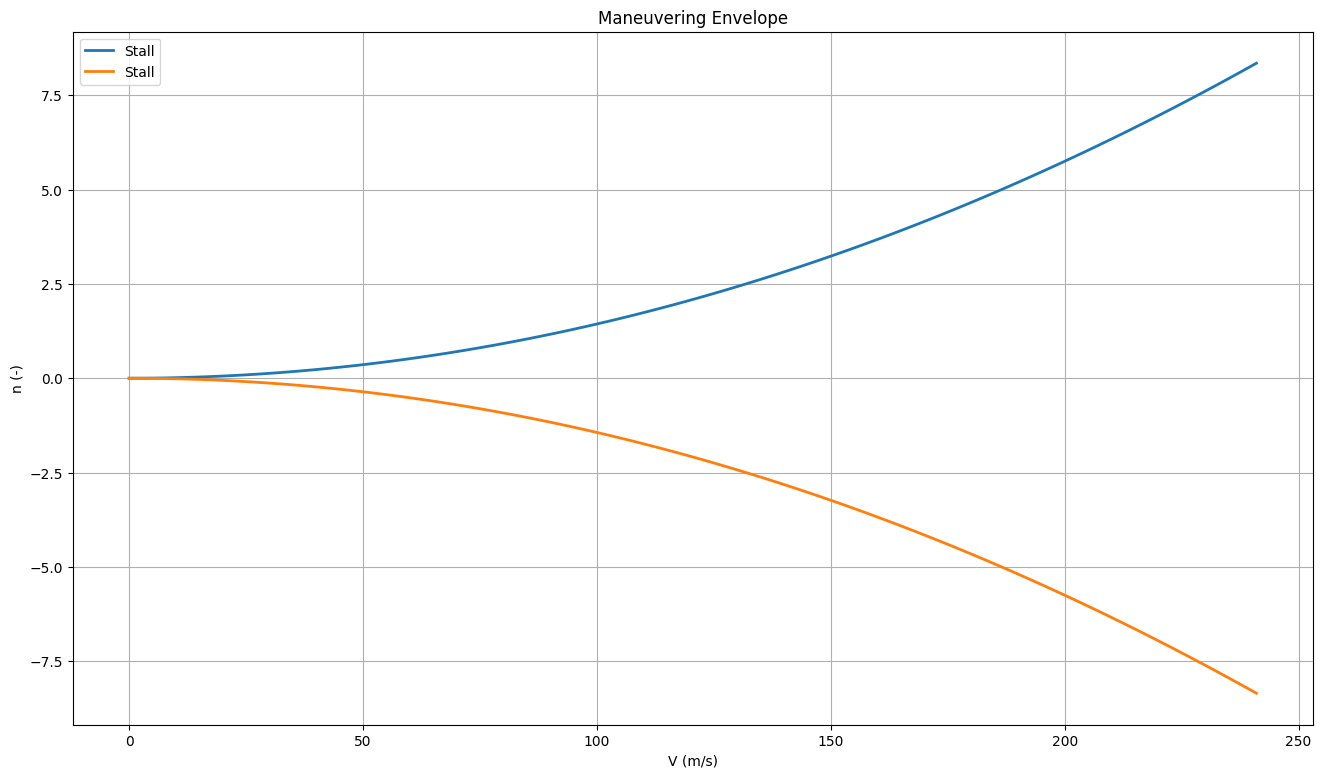

In [15]:
def compute_stall_boundary(V_min, V_max, n_points, rho, CL_max, Weight, S_ref):
    print("Computing stall boundary...")
    stall_coeff = 0.5 * rho * CL_max / (Weight / S_ref)
    print(f"W/S: {Weight / S_ref:.3f} N/m^2")
    print(f"Stall coefficient: {stall_coeff:.6f}")

    V = np.linspace(V_min, V_max, n_points)
    n_Stall = stall_coeff * V**2

    return V, n_Stall, stall_coeff

# Parameters
# Recourse: https://en.wikipedia.org/wiki/Boeing_787_Dreamliner
V_min = 0          # m/s, minimum speed
V_max = 241        # m/s, maximum speed
n_points = 100     # number of points in the speed range


rho = 1.225        # kg/m^3, air density at conditions of sea level
CL_max = 1.6       # maximum lift coefficient
MTOW = 227900      # kg, maximum takeoff weight
g = 9.81           # m/s^2, acceleration due to gravity
Weight = MTOW * g  *1.15 # N
S_ref =  377      # m^2, reference wing area

Boundary_V, Boundary_n_Stall, stall_coeff = compute_stall_boundary(V_min, V_max, n_points, rho, CL_max, Weight, S_ref)

V = np.linspace(V_min, V_max, n_points)

plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope')
plt.xlabel("V (m/s)")
plt.ylabel("n (-)")
plt.plot(Boundary_V, Boundary_n_Stall, label='Stall', linestyle='-', linewidth=2, marker=None, markersize=8)
plt.plot(Boundary_V, -Boundary_n_Stall, label='Stall', linestyle='-', linewidth=2, marker=None, markersize=8)
plt.grid(True)
plt.legend(loc='best')
plt.show()

However, few aircraft can withstand the loads contributed by a sudden change of angle of attack to $\alpha_{crit}$. Thus, the FAR25 defines the maximum load factor that a transport-category airplane:

From: https://www.ecfr.gov/current/title-14/chapter-I/subchapter-C/part-25/subpart-C/subject-group-ECFR3e855ea22ea15d0/section-25.337
$$ n_{+,limit} \ge 2.1 + \frac{24,000}{W+10,000}$$
$$ n_{-,limit} \ge -1.0

Where according to FAR 25.337
$$ 3.8 \ge n_{+,limit} \ge 2.5$$
$$ n_{-,limit} \ge -1.0$$

Computed positive limit load factor is 2.15, so use 2.50 based on FAR 25 minimum.
Negative limit load factor: -1.00


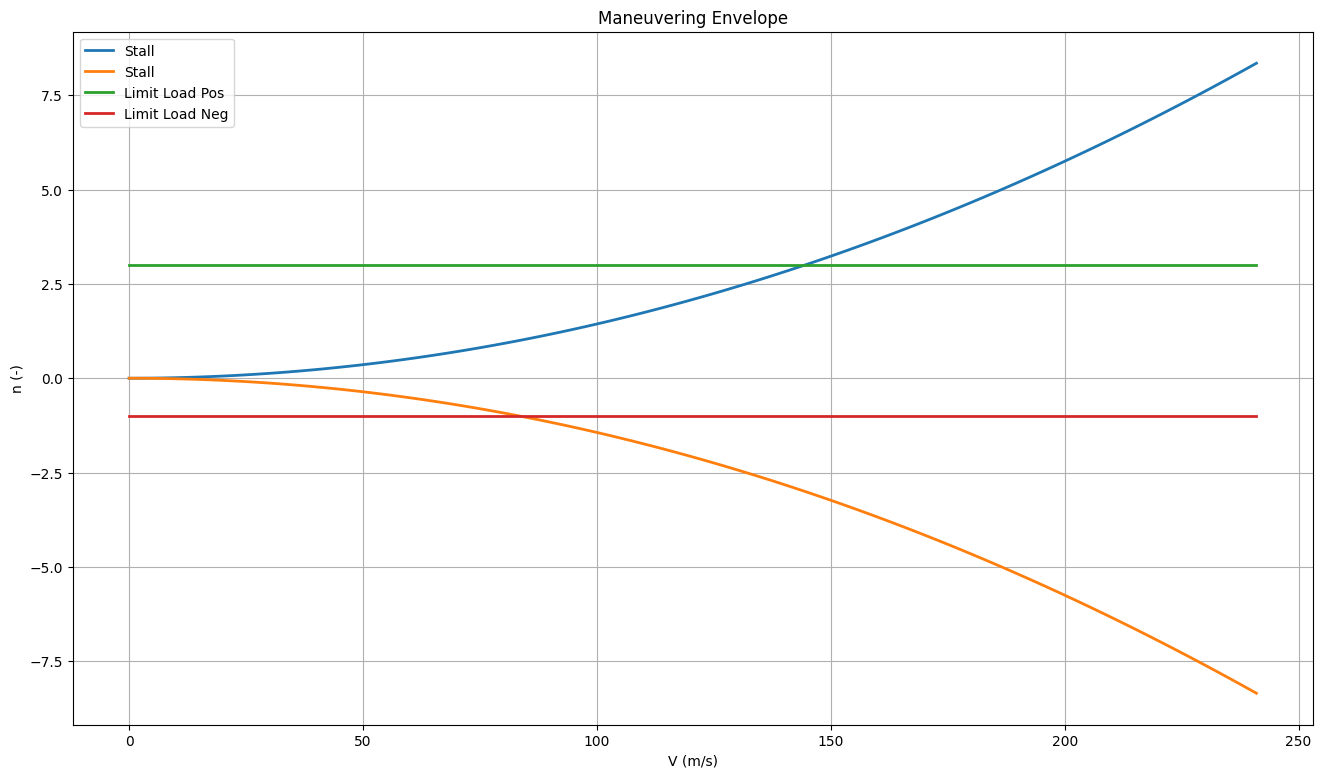

In [20]:
def compute_positive_limit_loads(weight_lb):
    n_pos_formula = 2.1 + 24000 / (weight_lb + 10000)  # FAR 25.337 formula

    if n_pos_formula < 2.5:
        print(f"Computed positive limit load factor is {n_pos_formula:.2f}, "
              f"so use 2.50 based on FAR 25 minimum.")
        selected_n_pos_limit = 2.5
    elif n_pos_formula > 3.8:
        print(f"Computed positive limit load factor is {n_pos_formula:.2f}, "
              f"so cap at 3.80 based on FAR 25 maximum.")
        selected_n_pos_limit = 3.8
    else:
        print(f"Computed positive limit load factor is {n_pos_formula:.2f}, "
              f"so use the computed value.")
        selected_n_pos_limit = n_pos_formula
    selected_n_pos_limit = n_pos_formula = 3
    return selected_n_pos_limit

MTOW_lb = 502500 # lb, maximum takeoff weight
n_pos_limit = compute_positive_limit_loads(MTOW_lb)
n_pos_limit = np.ones(100)*n_pos_limit

# For negative limit load factor, FAR 25.335 specifies -1.0 for transport category airplanes
n_neg_limit = -1.0*np.ones(100)
print(f"Negative limit load factor: {n_neg_limit[0]:.2f}")

plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope')
plt.xlabel("V (m/s)")
plt.ylabel("n (-)")
plt.plot(Boundary_V, Boundary_n_Stall, label='Stall', linestyle='-', linewidth=2, marker=None, markersize=8)
plt.plot(Boundary_V, -Boundary_n_Stall, label='Stall', linestyle='-', linewidth=2, marker=None, markersize=8)
plt.plot(V,n_pos_limit, label='Limit Load Pos', linestyle='-', linewidth=2, marker=None, markersize=8)
plt.plot(V,n_neg_limit, label='Limit Load Neg', linestyle='-', linewidth=2, marker=None, markersize=8)
plt.grid(True)
plt.legend(loc='best')
plt.show()

Let's make more sense of what this plot is showing us.

Intersection velocity for n_limit=3.00 is 144.49 m/s
Intersection velocity for n_limit=-1.00 is 83.42 m/s


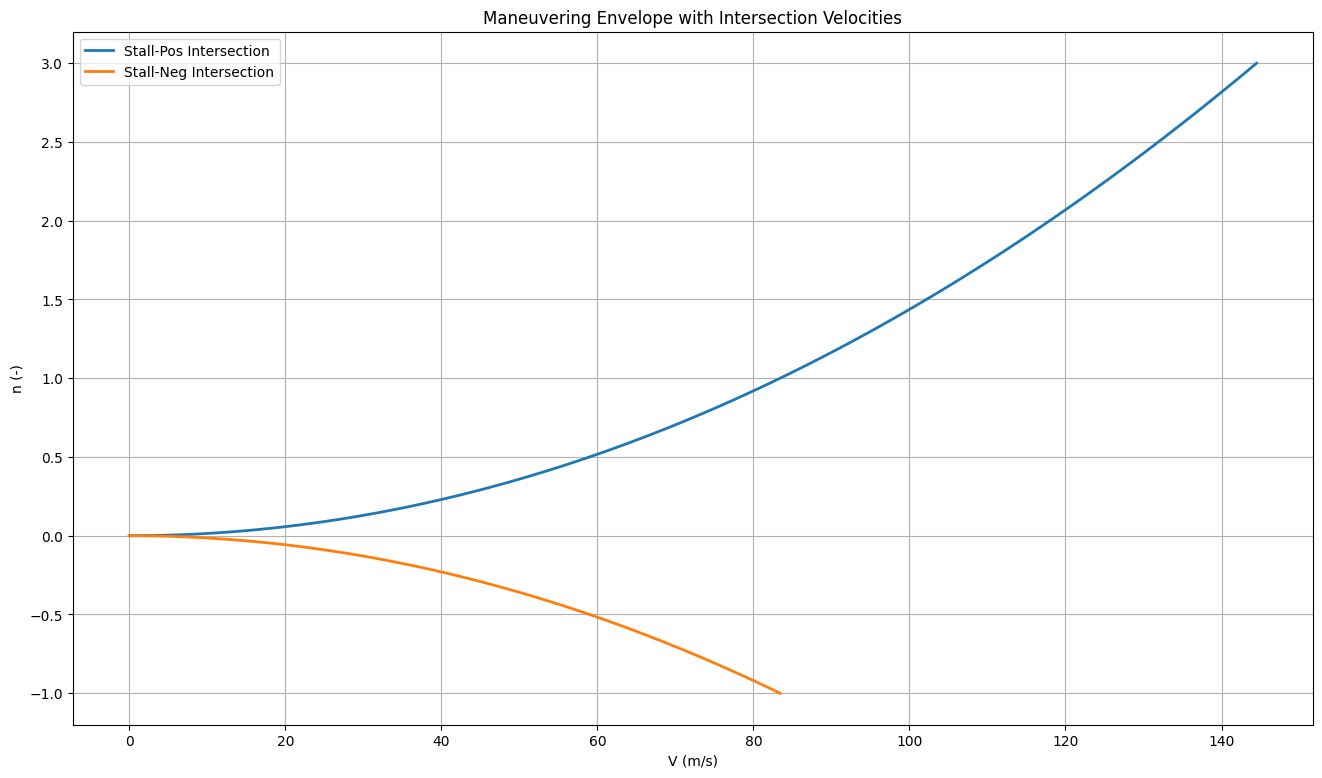

In [21]:
def compute_intersection_velocity(stall_coeff, n_limit):
    """
    Solve stall_coeff * V^2 = |n_limit|
    """
    int_V = np.sqrt(abs(n_limit) / stall_coeff)
    print(f"Intersection velocity for n_limit={n_limit:.2f} is {int_V:.2f} m/s")
    return int_V

# Compute intersection velocities for positive and negative limit load factors with in the stall boundary
V_stall_pos_end = compute_intersection_velocity(stall_coeff, n_pos_limit[0])
V_stall_pos = np.linspace(0, V_stall_pos_end, 100)

V_stall_neg_end = compute_intersection_velocity(stall_coeff, n_neg_limit[0])
V_stall_neg = np.linspace(0, V_stall_neg_end, 100)

# Compute the corresponding n values at the intersection points
n_stall_pos_intersection = stall_coeff * V_stall_pos**2
n_stall_neg_intersection = -stall_coeff * V_stall_neg**2

plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope with Intersection Velocities')
plt.xlabel("V (m/s)")
plt.ylabel("n (-)")
plt.plot(V_stall_pos, n_stall_pos_intersection  , label='Stall-Pos Intersection', linewidth=2, marker=None, markersize=8)
plt.plot(V_stall_neg, n_stall_neg_intersection  , label='Stall-Neg Intersection', linewidth=2, marker=None, markersize=8)
plt.grid(True)
plt.legend(loc='best')
plt.show()


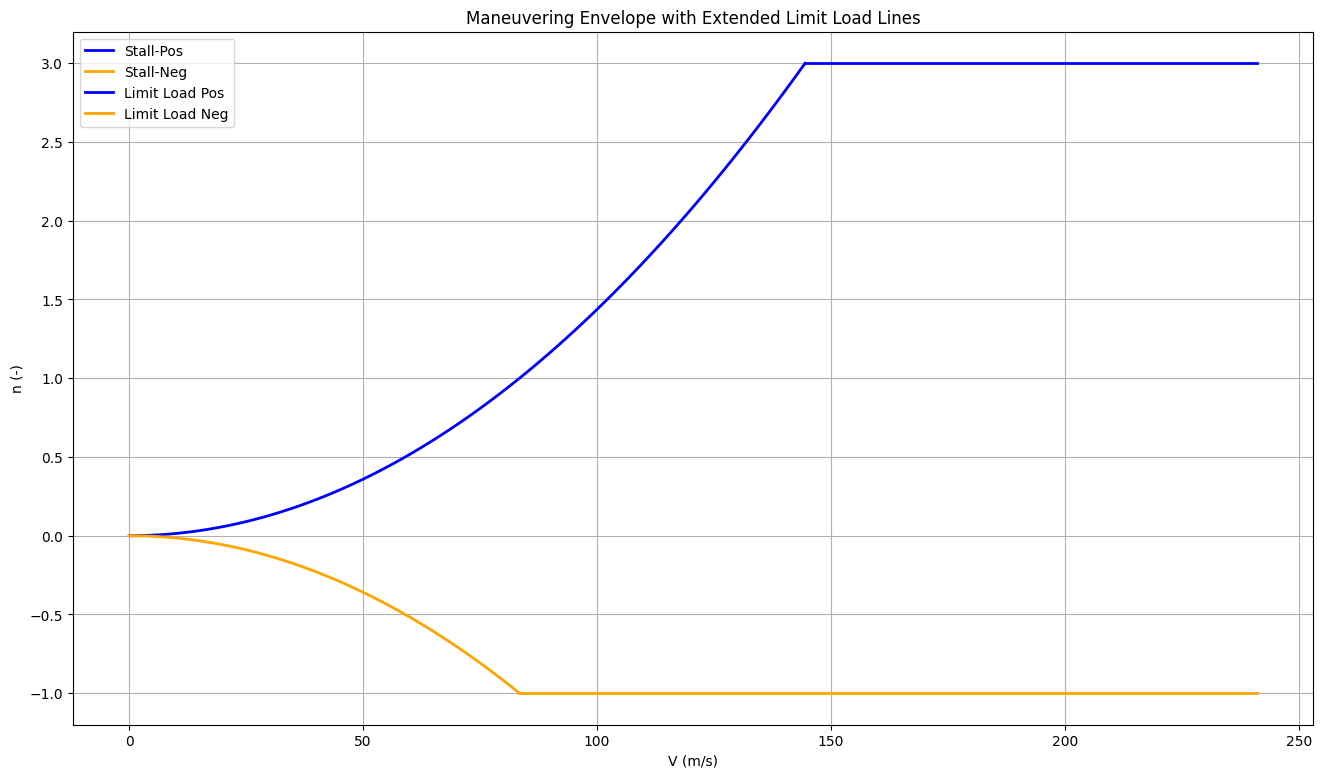

In [22]:
# Extend the positive limit load line to the right of the intersection point
V_pos_limit_extended = np.linspace(V_stall_pos_end, V_max, 100)
V_neg_limit_extended = np.linspace(V_stall_neg_end, V_max, 100)
n_pos_extended = n_pos_limit[0] * np.ones_like(V_pos_limit_extended)
n_neg_extended = n_neg_limit[0] * np.ones_like(V_neg_limit_extended)

plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope with Extended Limit Load Lines')
plt.xlabel("V (m/s)")
plt.ylabel("n (-)")
plt.plot(V_stall_pos, n_stall_pos_intersection  , label='Stall-Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_stall_neg, n_stall_neg_intersection  , label='Stall-Neg', linewidth=2, marker=None, markersize=8, color ='orange')
plt.plot(V_pos_limit_extended, n_pos_extended, label='Limit Load Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_neg_limit_extended, n_neg_extended, label='Limit Load Neg', linewidth=2, marker=None, markersize=8, color = 'orange')
plt.grid(True)
plt.legend(loc='best')
plt.show()

Lastly, we must consider the structural damage done due to stagnation pressure if the maximum allowable speed is exceeded. This puts a limit for a constant velocity.

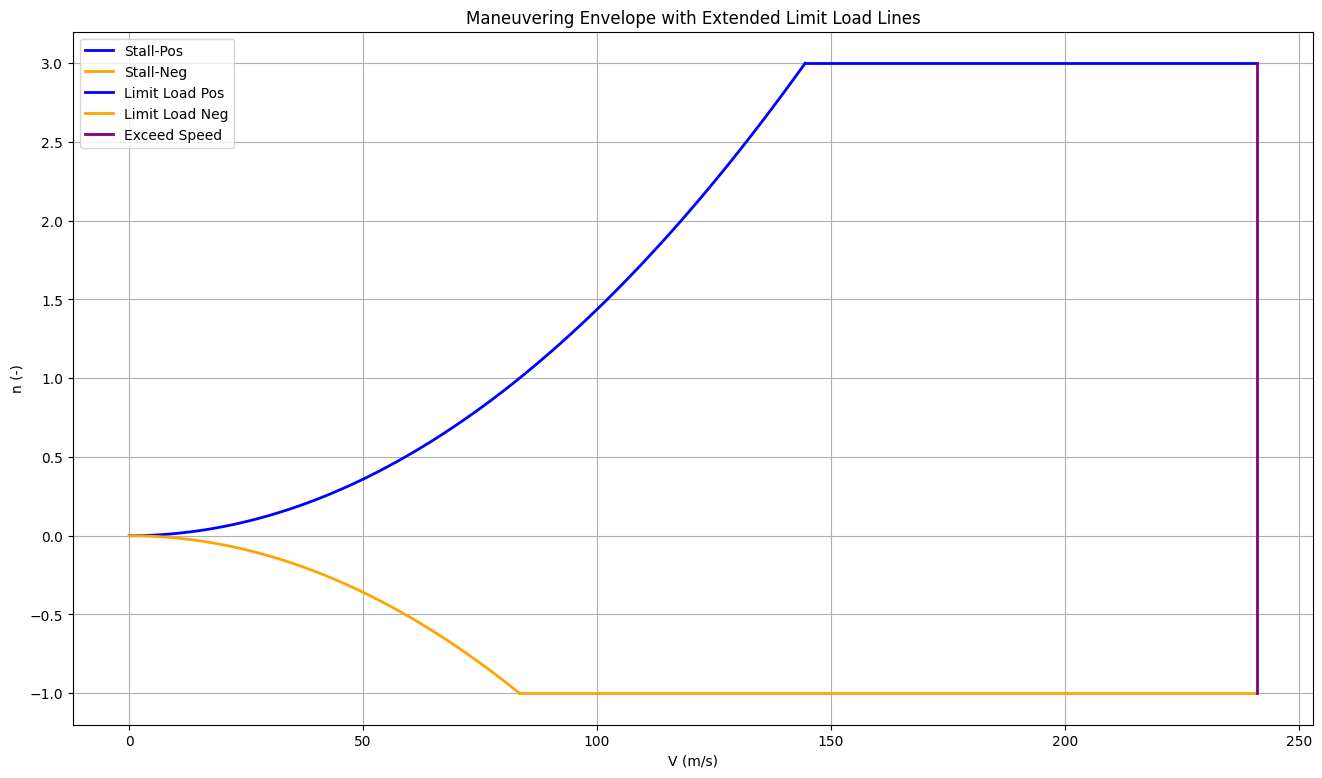

In [23]:
# lastly, we can also plot the exceed speed lines
V_exceed = V_max 
# vertical line goes from negative limit load to positive limit load
n_exceed_line = np.linspace(n_neg_limit[0], n_pos_limit[0], 100)
V_exceed_line = V_exceed * np.ones_like(n_exceed_line)


plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope with Extended Limit Load Lines')
plt.xlabel("V (m/s)")
plt.ylabel("n (-)")
plt.plot(V_stall_pos, n_stall_pos_intersection  , label='Stall-Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_stall_neg, n_stall_neg_intersection  , label='Stall-Neg', linewidth=2, marker=None, markersize=8, color ='orange')
plt.plot(V_pos_limit_extended, n_pos_extended, label='Limit Load Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_neg_limit_extended, n_neg_extended, label='Limit Load Neg', linewidth=2, marker=None, markersize=8, color = 'orange')
plt.plot(V_exceed_line, n_exceed_line,label='Exceed Speed', linewidth=2, color='purple')
plt.grid(True)
plt.legend(loc='best')
plt.show()

### Part 2. V-n diagram under gust consideration


The result shows the envelope in which the plane is able to maneuver. However, at any given time, gusts can occur and increase the loads of the structure. These must be taken into account according to FAR25 regulations. Let's review those. 

Vertical gust velocities $U_{de}$ during cruise:
- $U_{de}$ @ sea level: 56 ft/s
- $U_{de}$ @ 15000 ft: 44 ft/s
- $U_{de}$ @ 50000 ft: 26 ft/s

Source: https://www.ecfr.gov/current/title-14/chapter-I/subchapter-C/part-25/subpart-C/subject-group-ECFR3e855ea22ea15d0/section-25.341

Vertical gust velocities $U_{de}$ during dive: 50\% of values during cruise

To translate these velocities into additional loads, we use the gust load equation: $$n = 1 + \frac{C_{L_{\alpha}}k_gU_{de}V\rho}{2\frac{W}{S}}$$, where $k_g = \frac{0.88\mu_g}{\mu_g + 5.3}$ and $\mu_g = \frac{2W}{C_{L_{\alpha}}S\bar{c}}$. $C_{L_{\alpha}}$ is the lift slope, $\bar{c}$ the mean chord length.

In [7]:
def compute_k_g(weight, lift_slope, S_ref, c_bar):
    mu_g = 2*weight / (lift_slope * S_ref * c_bar)
    k_g = 0.88 * mu_g /(1 + mu_g)
    print(f"Computed k_g: {k_g:.3f} N/m^2 per unit CL")
    print(f"Computed mu_g: {mu_g:.3f}")
    return k_g

### Estimation of $\bar{c}$

A directly published value of the Boeing 787-8 mean aerodynamic chord $\bar{c}$ was not readily available, so it was approximated using the wing area and wingspan:

$$
\bar{c} \approx \frac{S}{b}
$$

With $S = 377.00\ \text{m}^2$ and $b = 60.12\ \text{m}$,

$$
\bar{c} \approx \frac{377.00}{60.12} \approx 6.27\ \text{m}
$$

Therefore, $\bar{c} \approx 6.27\ \text{m}$ was used in the gust-load calculation as a preliminary approximation.

In [8]:
b = 60.12          # m, wingspan
c_bar = S_ref / b  # m, mean aerodynamic chord
print(f"Computed mean aerodynamic chord: {c_bar:.3f} m")

Computed mean aerodynamic chord: 6.271 m


### Assumed Lift-Curve Slope, $C_{L_\alpha}$

Since a directly published lift-curve slope value for the Boeing 787-8 could not be readily found from public sources, a preliminary value of

$$
C_{L_\alpha} = 5 \ \text{rad}^{-1}
$$

was assumed for the present analysis. This is a reasonable estimate for a finite swept transport aircraft wing in clean configuration and is lower than the ideal 2D airfoil value of $2\pi \approx 6.28 \ \text{rad}^{-1}$, as expected due to finite-wing and sweep effects.

For cases where aerodynamic data are available, the lift-curve slope should be determined directly from the slope of the $C_L$ versus $\alpha$ curve in the approximately linear region, i.e.,

$$
C_{L_\alpha} = \frac{dC_L}{d\alpha}
$$

or estimated from a linear fit to the $C_L$-$\alpha$ data over the pre-stall range.

In [9]:
lift_slope = 5     # 1/rad
k_g = compute_k_g(Weight, lift_slope, S_ref, c_bar)

Computed k_g: 0.878 N/m^2 per unit CL
Computed mu_g: 378.277


### Recall:
Vertical gust velocities $U_{de}$ during cruise:
- $U_{de}$ @ sea level: 56 ft/s
- $U_{de}$ @ 15000 ft: 44 ft/s
- $U_{de}$ @ 50000 ft: 26 ft/s

Vertical gust velocities $U_{de}$ during dive: 50\% of values during cruise

In [10]:
def air_density_nasa_si(altitude_m):
    if altitude_m < 0:
        raise ValueError("Altitude must be non-negative.")

    # Troposphere
    if altitude_m <= 11000:
        T = 15.04 - 0.00649 * altitude_m + 273.15   # K
        p = 101290 * (T / 288.08) ** 5.256          # Pa

    # Lower stratosphere
    elif altitude_m <= 25000:
        T = -56.46 + 273.15                         # K
        p = 22650 * math.exp(1.73 - 0.000157 * altitude_m)   # Pa

    else:
        raise ValueError("This simplified NASA model here is set up only up to 25,000 m.")

    rho = p / (287.05 * T)   # kg/m^3
    return rho

def ft_per_s_to_m_per_s(speed_ft_s):
    m_per_s = speed_ft_s * 0.3048
    return m_per_s

def ft_to_m(altitude_ft):
    altitude_m = altitude_ft * 0.3048
    return altitude_m

U_de_sl = ft_per_s_to_m_per_s(56)    # m/s
U_de_15kft = ft_per_s_to_m_per_s(44)  # m/s
U_de_50kft = ft_per_s_to_m_per_s(26)  # m/s
print(f"Vertical gust velocity at sea level: {U_de_sl:.2f} m/s")
print(f"Vertical gust velocity at 15,000 ft: {U_de_15kft:.2f} m/s")
print(f"Vertical gust velocity at 50,000 ft: {U_de_50kft:.2f} m/s")

U_de_sl_dive = U_de_sl * 0.5
U_de_15kft_dive = U_de_15kft * 0.5
U_de_50kft_dive = U_de_50kft * 0.5
print(f"Vertical gust velocity at sea level during dive: {U_de_sl_dive:.2f} m/s")
print(f"Vertical gust velocity at 15,000 ft during dive: {U_de_15kft_dive:.2f} m/s")
print(f"Vertical gust velocity at 50,000 ft during dive: {U_de_50kft_dive:.2f} m/s")

rho_sl = air_density_nasa_si(0)
print(f"Air density at sea level: {rho_sl:.3f} kg/m^3")
rho_15kft = air_density_nasa_si(ft_to_m(15000))
print(f"Air density at 15,000 ft: {rho_15kft:.3f} kg/m^3")
rho_50kft = air_density_nasa_si(ft_to_m(50000))
print(f"Air density at 50,000 ft: {rho_50kft:.6f} kg/m^3")


Vertical gust velocity at sea level: 17.07 m/s
Vertical gust velocity at 15,000 ft: 13.41 m/s
Vertical gust velocity at 50,000 ft: 7.92 m/s
Vertical gust velocity at sea level during dive: 8.53 m/s
Vertical gust velocity at 15,000 ft during dive: 6.71 m/s
Vertical gust velocity at 50,000 ft during dive: 3.96 m/s
Air density at sea level: 1.227 kg/m^3
Air density at 15,000 ft: 0.773 kg/m^3
Air density at 50,000 ft: 0.187704 kg/m^3


### Recall:
We have $$n = 1 + \frac{C_{L_{\alpha}}k_g}{2\frac{W}{S}} \cdot U_{de}V\rho$$, where $k_g = \frac{0.88\mu_g}{\mu_g + 5.3}$ and $\mu_g = \frac{2W}{C_{L_{\alpha}}S\bar{c}}$. $C_{L_{\alpha}}$ is the lift slope, $\bar{c}$ the mean chord length.

In [11]:
constant = lift_slope * k_g /(2 * Weight / S_ref)
print(f"Constant term for gust boundary: {constant:.6f} (m/s)^-2")

Constant term for gust boundary: 0.000370 (m/s)^-2


Once the necessary values of your aircraft are obtained, the gust load can be determined. Here are exemplary values for the Boeing 787-8.
- $\mu_g$ = 118.605
- $k_g$ = 0.873 N/$m^2$
$$n = 1 + 0.000368 \cdot \rho U_{de}V$$

In [12]:
rho_values = [rho_sl, rho_15kft, rho_50kft]
U_de_values = [U_de_sl, U_de_15kft, U_de_50kft]
altitude_labels = ["Sea Level", "15,000 ft", "50,000 ft"]

gust_boundary_list = []

for altitude, rho, U_de in zip(altitude_labels, rho_values, U_de_values):
    gust_boundary = constant * rho * U_de
    gust_boundary_list.append({
        "Altitude": altitude,
        "rho": rho,
        "U_de": U_de,
        "constant_term": gust_boundary
    })

gust_boundary_df = pd.DataFrame(gust_boundary_list)
gust_boundary_df

,Altitude,rho,U_de,constant_term
0,Sea Level,1.226878,17.0688,0.007748
1,"15,000 ft",0.772622,13.4112,0.003834
2,"50,000 ft",0.187704,7.9248,0.000550


In [13]:
# For dive condition, we can also compute the gust boundary values
U_de_dive_values = [U_de_sl_dive, U_de_15kft_dive, U_de_50kft_dive]

gust_boundary_dive_list = []

for altitude, rho, U_de_dive in zip(altitude_labels, rho_values, U_de_dive_values):
    gust_boundary_dive = constant * rho * U_de_dive
    gust_boundary_dive_list.append({
        "Altitude": altitude,
        "rho": rho,
        "U_de_dive": U_de_dive,
        "constant_term_dive": gust_boundary_dive
    })
gust_boundary_dive_df = pd.DataFrame(gust_boundary_dive_list)
gust_boundary_dive_df

,Altitude,rho,U_de_dive,constant_term_dive
0,Sea Level,1.226878,8.5344,0.003874
1,"15,000 ft",0.772622,6.7056,0.001917
2,"50,000 ft",0.187704,3.9624,0.000275


Now, the gust lines can be obtained at desired altitudes. E.g., the gust loads at sea level during cruise will be $n = 1 + 0.007704*V_C$, and $n = 1 + 0.003852*V_D$ for design dive speeds.

### Assumption for \(V_C\)

In the absence of a directly specified design cruise speed $(V_C)$, a preliminary estimate was taken as

$$
V_C \approx 0.8\,V_D
$$

This comes from the FAR 25 design airspeed requirement that $(V_D)$ must be selected such that $(\frac{V_C}{M_C})$ is not greater than $(0.8,\frac{V_D}{M_D})$. Therefore, for a simplified preliminary analysis, taking $V_C \approx 0.8 \cdot V_D)$ provides a reasonable first estimate when a more specific aircraft design value is not available. 

Source:https://www.ecfr.gov/current/title-14/chapter-I/subchapter-C/part-25/subpart-C/subject-group-ECFR3e855ea22ea15d0/section-25.335

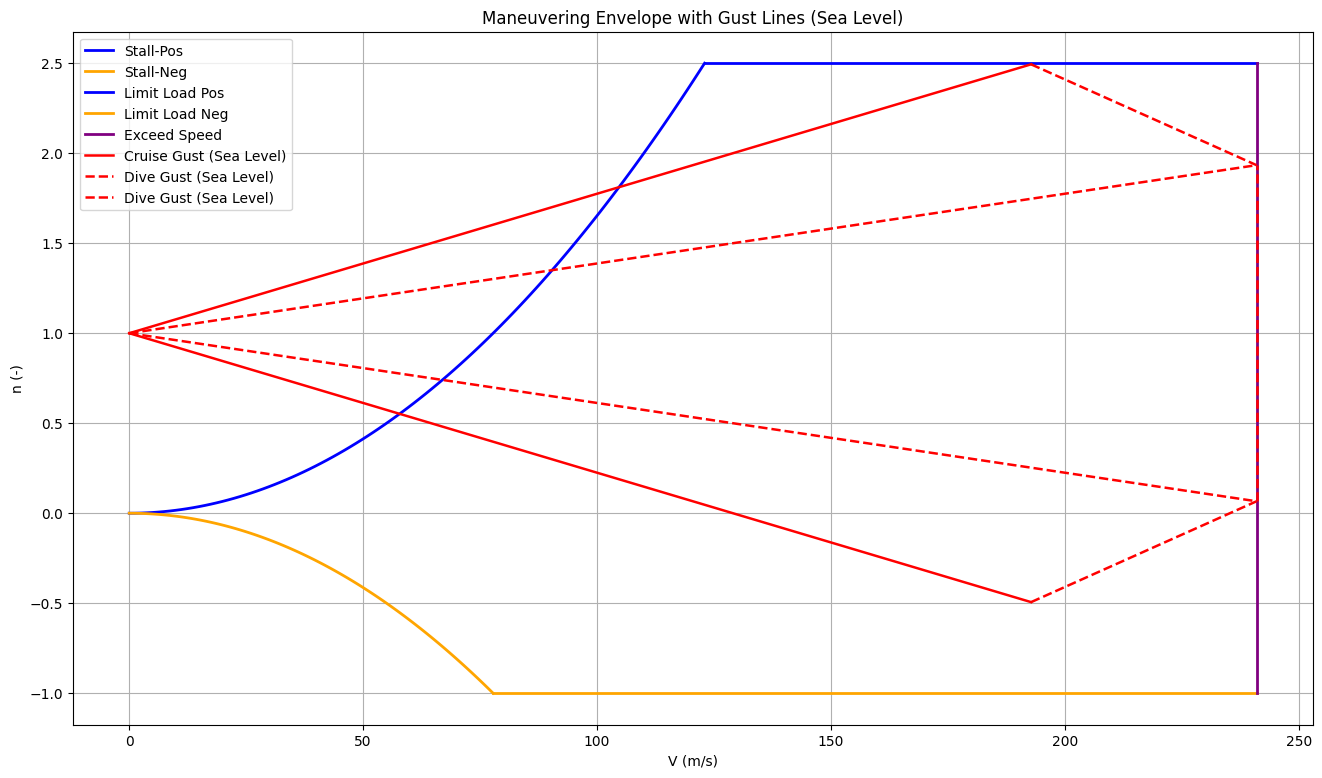

In [14]:
V_dive = V_max
V_gust = V_max * 0.8

def plot_gust_case(selected_altitude, V_gust, V_dive):
    # Plotting gust line from 0 to V_gust for cruise, and from 0 to V_dive for dive
    V_gust_array = np.linspace(0, V_gust, 200)
    V_dive_array = np.linspace(0, V_dive, 200)
    
    # Plotting a straight line connecting the cruise gust line endpoint at V_gust and the dive gust line endpoint at V_dive
    V_dive_connect_array = np.linspace(V_gust, V_dive, 200)

    plt.figure(figsize=(16,9))
    plt.title(f'Maneuvering Envelope with Gust Lines ({selected_altitude})')
    plt.xlabel("V (m/s)")
    plt.ylabel("n (-)")

    # Existing maneuvering envelope
    plt.plot(V_stall_pos, n_stall_pos_intersection,
             label='Stall-Pos', linewidth=2, color='blue')
    plt.plot(V_stall_neg, n_stall_neg_intersection,
             label='Stall-Neg', linewidth=2, color='orange')
    plt.plot(V_pos_limit_extended, n_pos_extended,
             label='Limit Load Pos', linewidth=2, color='blue')
    plt.plot(V_neg_limit_extended, n_neg_extended,
             label='Limit Load Neg', linewidth=2, color='orange')
    plt.plot(V_exceed_line, n_exceed_line,
             label='Exceed Speed', linewidth=2, color='purple')

    case_color = 'red'

    # Cruise
    row_cruise = gust_boundary_df[gust_boundary_df["Altitude"] == selected_altitude].iloc[0]
    gust_coeff = row_cruise["constant_term"]

    n_gust_pos = 1 + gust_coeff * V_gust_array
    n_gust_neg = 1 - gust_coeff * V_gust_array

    plt.plot(V_gust_array, n_gust_pos,
             color=case_color, linewidth=1.8, linestyle='-',
             label=f'Cruise Gust ({selected_altitude})')
    plt.plot(V_gust_array, n_gust_neg,
             color=case_color, linewidth=1.8, linestyle='-',
             label='_nolegend_')

    # Dive
    row_dive = gust_boundary_dive_df[gust_boundary_dive_df["Altitude"] == selected_altitude].iloc[0]
    gust_coeff_dive = row_dive["constant_term_dive"]

    # Original dive gust line (not connected to cruise gust line)
    n_gust_pos_dive_og = 1 + gust_coeff_dive * V_dive_array
    n_gust_neg_dive_og = 1 - gust_coeff_dive * V_dive_array

    plt.plot(V_dive_array, n_gust_pos_dive_og,
             color=case_color, linewidth=1.8, linestyle='--',
             label=f'Dive Gust ({selected_altitude})')
    plt.plot(V_dive_array, n_gust_neg_dive_og,
             color=case_color, linewidth=1.8, linestyle='--',
             label='_nolegend_')

    # endpoint at V_C from cruise gust line
    n_gust_pos_at_VC = 1 + gust_coeff * V_gust_array[-1]
    n_gust_neg_at_VC = 1 - gust_coeff * V_gust_array[-1]

    # endpoint at V_D from dive gust line
    n_gust_pos_at_VD = 1 + gust_coeff_dive * V_dive_array[-1]
    n_gust_neg_at_VD = 1 - gust_coeff_dive * V_dive_array[-1]

    # straight line between V_C and V_D
    n_gust_pos_dive = np.linspace(n_gust_pos_at_VC, n_gust_pos_at_VD, len(V_dive_array))
    n_gust_neg_dive = np.linspace(n_gust_neg_at_VC, n_gust_neg_at_VD, len(V_dive_array))

    plt.plot(V_dive_connect_array, n_gust_pos_dive,
             color=case_color, linewidth=1.8, linestyle='--',
             label=f'Dive Gust ({selected_altitude})')
    plt.plot(V_dive_connect_array, n_gust_neg_dive,
             color=case_color, linewidth=1.8, linestyle='--',
             label='_nolegend_')
    
    # Vertical line at V_dive between negative and positive dive gust endpoints
    plt.plot(
        [V_dive, V_dive],
        [n_gust_neg_at_VD, n_gust_pos_at_VD],
        color=case_color,
        linewidth=1.8,
        linestyle='--',
        label='_nolegend_'
    )
    plt.grid(True)
    plt.legend(loc='best')
    plt.show()


plot_gust_case("Sea Level", V_gust, V_dive)

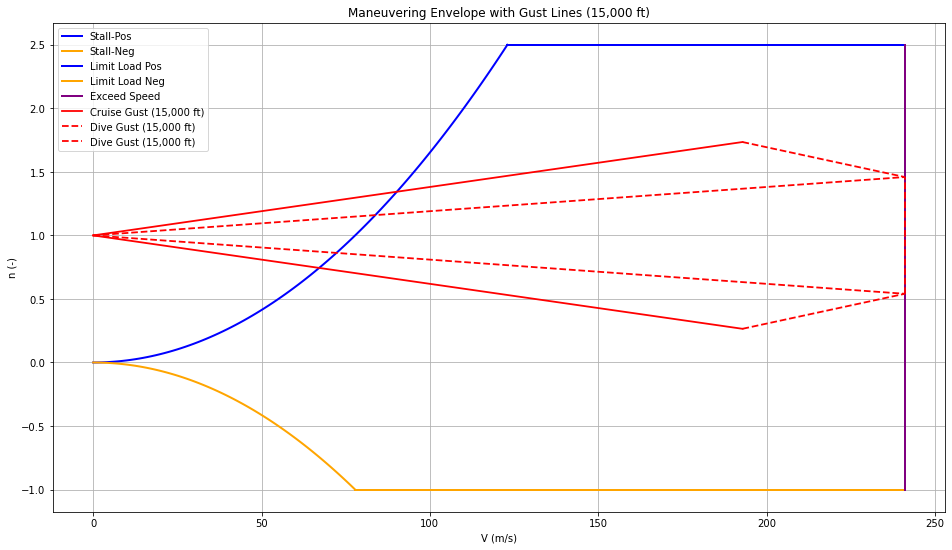

In [60]:
plot_gust_case("15,000 ft", V_gust, V_dive)

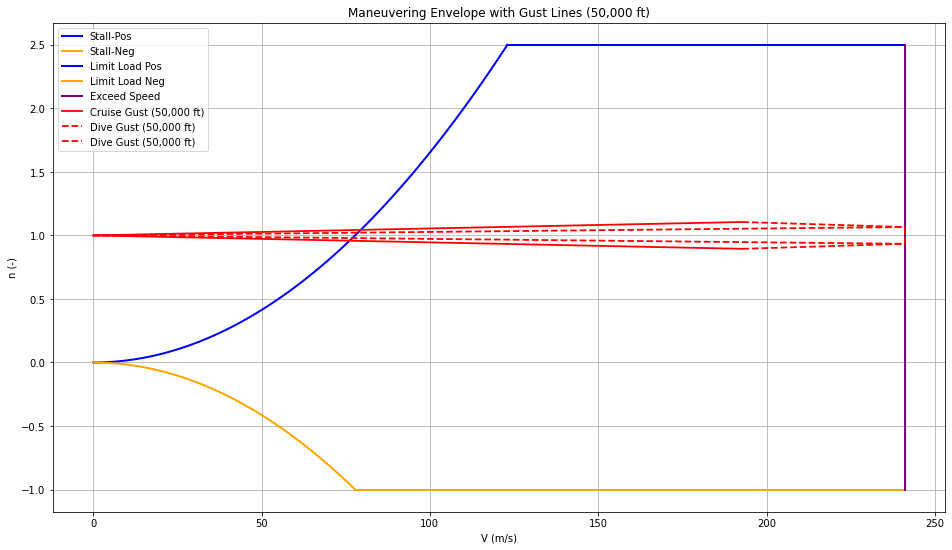

In [61]:
plot_gust_case("50,000 ft", V_gust, V_dive)

Per FAR25, the gust lines are then linearly connected. In the case of the Boeing 787-8, the gust lines do not pose an additional restriction to the flight envelope. Therefore, no changes are required and we have found our flight envelope!